In [ ]:
import pandas as pd
import numpy as np 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style chung cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Sửa lại đường dẫn: lùi ra ngoài thư mục Notebooks để thấy processed_chunks
path = '../processed_chunks/' 

all_files = glob.glob(os.path.join(path, "train_*.pkl"))

# Kiểm tra xem có tìm thấy file nào không
if not all_files:
    print("Không tìm thấy file nào! Hãy kiểm tra lại đường dẫn.")
else:
    print(f"Tìm thấy {len(all_files)} files. Đang đọc...")
    df_list = [pd.read_pickle(f) for f in all_files]
    full_df = pd.concat(df_list, ignore_index=True)
    print(f"Thành công! Tổng số dòng: {len(full_df)}")


Tìm thấy 18 files. Đang đọc...
Thành công! Tổng số dòng: 1708337


In [ ]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1708337 entries, 0 to 1708336
Data columns (total 59 columns):
 #   Column                                        Dtype         
---  ------                                        -----         
 0   channelGrouping                               object        
 1   date                                          datetime64[ns]
 2   fullVisitorId                                 object        
 3   visitId                                       int64         
 4   visitNumber                                   int64         
 5   visitStartTime                                int64         
 6   device_browser                                object        
 7   device_operatingSystem                        object        
 8   device_isMobile                               bool          
 9   device_deviceCategory                         object        
 10  geoNetwork_continent                          object        
 11  geoNetwork_subContinent            

In [ ]:
full_df.head()

,channelGrouping,date,fullVisitorId,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,device_isMobile,device_deviceCategory,...,Date_Is_month_start,Date_Is_quarter_end,Date_Is_quarter_start,Date_Is_year_end,Date_Is_year_start,visitStartTime_datetime,Date_Hour,transactionRevenue,transactionRevenue_dollar,target_log_revenue
0,Organic Search,2017-10-16,3162355547410993243,1508198450,1,1508198450,Firefox,Windows,False,desktop,...,0,0,0,0,0,2017-10-17 00:00:50,0,0.0,0.0,0.0
1,Referral,2017-10-16,8934116514970143966,1508176307,6,1508176307,Chrome,Chrome OS,False,desktop,...,0,0,0,0,0,2017-10-16 17:51:47,17,0.0,0.0,0.0
2,Direct,2017-10-16,7992466427990357681,1508201613,1,1508201613,Chrome,Android,True,mobile,...,0,0,0,0,0,2017-10-17 00:53:33,0,0.0,0.0,0.0
3,Organic Search,2017-10-16,9075655783635761930,1508169851,1,1508169851,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 16:04:11,16,0.0,0.0,0.0
4,Organic Search,2017-10-16,6960673291025684308,1508190552,1,1508190552,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 21:49:12,21,0.0,0.0,0.0


In [ ]:
full_df.isnull().sum()

channelGrouping                                       0
date                                                  0
fullVisitorId                                         0
visitId                                               0
visitNumber                                           0
visitStartTime                                        0
device_browser                                       12
device_operatingSystem                            11815
device_isMobile                                       0
device_deviceCategory                                 0
geoNetwork_continent                               2517
geoNetwork_subContinent                            2517
geoNetwork_country                                 2517
geoNetwork_region                                982733
geoNetwork_metro                                1319855
geoNetwork_city                                  998826
geoNetwork_networkDomain                         768845
totals_visits                                   

In [ ]:
full_df.nunique().sort_values(ascending=False)

visitStartTime                                  1667423
visitStartTime_datetime                         1667423
visitId                                         1665802
fullVisitorId                                   1323730
trafficSource_adwordsClickInfo.gclId              59009
geoNetwork_networkDomain                          41980
totals_totalTransactionRevenue                     8507
target_log_revenue                                 7252
transactionRevenue                                 7252
totals_transactionRevenue                          7252
transactionRevenue_dollar                          7252
totals_timeOnSite                                  4775
trafficSource_keyword                              4546
trafficSource_referralPath                         3197
geoNetwork_city                                     954
date                                                638
geoNetwork_region                                   481
visitNumber                                     

## 📊 Data Dictionary — Google Merchandise Store

**Dataset:** Google Analytics session-level data
**Shape:** 1,708,337 rows × 59 columns · **Memory:** ~697 MB
**Target:** `target_log_revenue` — log1p(transaction revenue)

---

### 1. 🔑 Session Identification (6 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `fullVisitorId` | object | 0 | Unique ID for each visitor |
| `visitId` | int64 | 0 | Session ID (unique per visitor) |
| `visitNumber` | int64 | 0 | Nth visit of this visitor (1 = first visit) |
| `visitStartTime` | int64 | 0 | UNIX timestamp of session start |
| `visitStartTime_datetime` | datetime64 | 0 | Human-readable session start time |
| `date` | datetime64 | 0 | Date of the session |

---

### 2. 📱 Device Information (4 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `device_browser` | object | 12 | Browser used (Chrome, Safari, ...) |
| `device_operatingSystem` | object | 11,815 | OS of the device |
| `device_isMobile` | bool | 0 | True if session was from mobile |
| `device_deviceCategory` | object | 0 | Device type: desktop / mobile / tablet |

---

### 3. 🌍 Geographic Information (7 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `geoNetwork_continent` | object | 2,517 | Continent of the visitor |
| `geoNetwork_subContinent` | object | 2,517 | Sub-continent |
| `geoNetwork_country` | object | 2,517 | Country of the visitor |
| `geoNetwork_region` | object | 982,733 | 🟡 Region/state — high nulls |
| `geoNetwork_metro` | object | 1,319,855 | 🔴 Metro area — very high nulls |
| `geoNetwork_city` | object | 998,826 | 🔴 City — very high nulls |
| `geoNetwork_networkDomain` | object | 768,845 | 🟡 ISP/network domain |

---

### 4. 📈 Session Totals (11 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `totals_visits` | int64 | 0 | Always 1 (one row = one session) |
| `totals_hits` | int64 | 0 | Number of hits in session |
| `totals_pageviews` | int64 | 0 | Pages viewed in session |
| `totals_bounces` | int64 | 0 | 1 if session bounced, else 0 |
| `totals_newVisits` | int64 | 0 | 1 if first-ever visit, else 0 |
| `totals_sessionQualityDim` | int64 | 0 | GA session quality score (1–100) |
| `totals_timeOnSite` | int64 | 0 | Time on site in seconds |
| `totals_transactions` | int64 | 0 | Number of transactions in session |
| `totals_transactionRevenue` | float64 | 0 | Revenue × 10⁶ (raw GA format) (unit: micro) |
| `totals_totalTransactionRevenue` | float64 | 0 | Total revenue × 10⁶ |
| `transactionRevenue` | float64 | 0 | Revenue cleaned (= totals / 10⁶) |

---

### 5. 🚦 Traffic Source (13 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `channelGrouping` | object | 0 | Channel: Organic, Direct, Referral, ... |
| `trafficSource_source` | object | 70 | Traffic source (google, direct, ...) |
| `trafficSource_medium` | object | 566,091 | 🟡 Medium: organic, cpc, referral, ... |
| `trafficSource_campaign` | object | 1,604,526 | 🔴 Campaign name — mostly null |
| `trafficSource_keyword` | object | 0 | Search keyword |
| `trafficSource_referralPath` | object | 0 | Referral URL path |
| `trafficSource_isTrueDirect` | bool | 0 | True if confirmed direct traffic |
| `trafficSource_adContent` | object | 0 | Ad content label |
| `trafficSource_adwordsClickInfo.page` | int64 | 0 | AdWords page number |
| `trafficSource_adwordsClickInfo.slot` | object | 0 | Ad slot position |
| `trafficSource_adwordsClickInfo.gclId` | object | 0 | Google Click ID |
| `trafficSource_adwordsClickInfo.adNetworkType` | object | 0 | Ad network type |
| `trafficSource_adwordsClickInfo.isVideoAd` | bool | 0 | True if video ad click |

---

### 6. 🗓️ Date Features (13 columns — engineered)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `Date_Year` | int32 | 0 | Year |
| `Date_Month` | int32 | 0 | Month (1–12) |
| `Date_Day` | int32 | 0 | Day of month (1–31) |
| `Date_Dayofweek` | int32 | 0 | Day of week (0=Mon, 6=Sun) |
| `Date_Dayofyear` | int32 | 0 | Day of year (1–365) |
| `Date_Week` | Int64 | 0 | ISO week number |
| `Date_Hour` | int32 | 0 | Hour of visit (0–23) |
| `Date_Is_month_end` | int64 | 0 | 1 if last day of month |
| `Date_Is_month_start` | int64 | 0 | 1 if first day of month |
| `Date_Is_quarter_end` | int64 | 0 | 1 if last day of quarter |
| `Date_Is_quarter_start` | int64 | 0 | 1 if first day of quarter |
| `Date_Is_year_end` | int64 | 0 | 1 if last day of year |
| `Date_Is_year_start` | int64 | 0 | 1 if first day of year |

---

### 7. 🎯 Target & Custom Dimensions (5 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `transactionRevenue_dollar` | float64 | 0 | Revenue in USD (cleaned) |
| `target_log_revenue` | float64 | 0 | **Model target** — log1p(revenue) |
| `customDimensions_count` | int64 | 0 | Number of custom dimensions |
| `customDimensions_index` | int64 | 0 | Custom dimension index |
| `customDimensions_value` | object | 0 | Custom dimension value |

---

### ⚠️ Missing Value — Cách xử lý

| Severity | Columns | Cách xử lý |
|---|---|---|
| 🔴 Rất cao (>50%) | `trafficSource_campaign` | Fill `"no_campaign"` — null = không chạy campaign |
| 🔴🟡 Cao | `geoNetwork_metro`, `geoNetwork_city`, `geoNetwork_region` | Fill `"unknown"` |
| 🟡 Cao (~33%) | `trafficSource_medium` | Fill `"none"` — chuẩn GA: null = direct/none |
| 🟡 Cao (~45%) | `geoNetwork_networkDomain` | Không dùng trong model — bỏ qua |
| 🟢 Thấp (<1%) | `device_operatingSystem`, `device_browser`, `trafficSource_source`, `geoNetwork_country`, `geoNetwork_subContinent`, `geoNetwork_continent` | Fill `"unknown"` |

> **Kết quả:** Sau xử lý tất cả cột đều có null = 0.

### 1. GIGO Audit 

Kiểm tra internal traffic, bot....

In [ ]:
# 1. Internal traffic (nhân viên test). Dấu hiệu: domain chứa google hoặc city = Mountain View -> test hệ thống, không mua thật 
internal_mask = (
    (full_df['geoNetwork_networkDomain'].astype(str).str.contains('google', na=False)) | 
    (full_df['geoNetwork_city'] == 'Mountain View')
)
print(f'Internal sessions: {internal_mask.sum():,}')
# 2. Bot/crawler: Các chương trình tự động crawl website, không phải người thật. Chúng để lại dấu hiệu bất thường như hits cao nhưng timeOnSite = 0
# pageview cao + bounce = 1 (vào rồi thoát ngay nhưng hits nhiều), browser lạ như ";__CT_JOB_ID..." -> bot không bao giờ mua hàng
bot_mask = (
    ((full_df['totals_hits'] > 500) & (full_df['totals_timeOnSite'] == 0)) |
    ((full_df['totals_pageviews'] > 500) & (full_df['totals_bounces'] == 1)) |
    (full_df['device_browser'].str.contains('CT_JOB_ID|ecgiwap', na=False, regex=True)))
print(f"Bot sessions: {bot_mask.sum():,}")

# 3. Tracking error: users chỉ xem 1 trang duy nhất rồi thoát (không thể vừa bounce vừa mua hàng vì cần min 3-4 pages: page sản phẩm -> giỏ hàng -> thanh toán -> xác nhận)
# bounce = 1 + revenue > 0 = lỗi tracking, không phải giao dịch thật
tracking_error_mask = ((full_df['totals_bounces'] == 1) & (full_df['transactionRevenue'] > 0))
print(f"Tracking errors: {tracking_error_mask.sum():,}")
print(f"Revenue từ nhóm này: ${full_df[tracking_error_mask]['transactionRevenue'].sum():,.2f}")


# 4. Fake Whale: pageviews = 1, timeonsite = 0, revenue lớn (chỉ xem 1 trang, không dành 1 giây nào trên size nhuwngmua hàng giá trị lớn)
fake_whale_mask = ((full_df['totals_pageviews'] <= 1) & (full_df['totals_timeOnSite']==0) & (full_df['transactionRevenue'] >0))
print(f"Fake whales: {fake_whale_mask.sum():,}")
print(f"Revenue trung bình: ${full_df[fake_whale_mask]['transactionRevenue'].mean():,.2f}")
print(f"Revenue max: ${full_df[fake_whale_mask]['transactionRevenue'].max():,.2f}")
print(f"Revenue tổng: ${full_df[fake_whale_mask]['transactionRevenue'].sum():,.2f}")

Internal sessions: 84,598
Bot sessions: 21
Tracking errors: 0
Revenue từ nhóm này: $0.00
Fake whales: 0
Revenue trung bình: $nan
Revenue max: $nan
Revenue tổng: $0.00


Kiểm tra tỷ lệ khách mua hàng thực sự, missing có chủ đích

In [ ]:
# Tỷ lệ khách mua hàng thực sự
buyers = (full_df['transactionRevenue'] > 0).sum()
total = len(full_df)
print(f'Khách có mua hàng: {buyers:,} ({buyers/total*100:.2f}%)')
print(f"Khách không mua   : {total-buyers:,} ({(total-buyers)/total*100:.2f}%)")

# Kiểm tra missing có chủ đích ở revenue (98-99% users không mua, chỉ 1-2% có revenue) -> extreme class imbalance
print(f"\nRevenue = 0      : {(full_df['transactionRevenue']==0).sum():,}")
print(f"Revenue > 0      : {(full_df['transactionRevenue']>0).sum():,}")
print(f"Revenue là null  : {full_df['transactionRevenue'].isnull().sum():,}")

Khách có mua hàng: 18,514 (1.08%)
Khách không mua   : 1,689,823 (98.92%)

Revenue = 0      : 1,689,823
Revenue > 0      : 18,514
Revenue là null  : 0


##### Với phần lọc nhiễu phi sản phẩm 
- 18,514 sessions có chênh lệch giữa transactionRevenue 
  và totalTransactionRevenue (tax + shipping)
- 75% hàng: tax/shipping ratio < 22% → bình thường
- 740 hàng: tax > revenue (ratio > 1) → bất thường
- max ratio = 300 → có thể là refund hoặc adjustment

QUYẾT ĐỊNH: 
  Dùng 'transactionRevenue' làm target thay vì 'totalTransactionRevenue'
  vì đây là giá trị hàng hóa thuần, không bị ảnh hưởng bởi 
  tax/shipping bất thường. 'target_log_revenue' đã được tính 
  đúng từ cột này → không cần xử lý thêm.


### 2. Funnel and Pageviews-Revenue

Bộ data là session-lvel, phễu được suy luận từ hits và pageviews:

- hits = 1-2: vào trang chủ, chưa xem gì <br>
- hits = 3-10: đang xem sản phẩm <br>
- hits = 11-20: xem nhiều, đang so sánh <br>
- hits = 20+: engagement cao, gần mua
- transactions = 1: đã thanh toán


In [ ]:
# Phân tích ngưỡng pageviews → conversion
bins   = [0, 2, 5, 10, 20, 50, 500]
labels = ['Trang chủ (1-2)', 'Xem SP (3-5)', 
          'Khám phá (6-10)', 'Engaged (11-20)',
          'Deep (21-50)', 'Power (50+)']

# Copy full_df để tạo funnel_stage (chỉ cho data understanding)
df_funnel = full_df.copy()
df_funnel['funnel_stage'] = pd.cut(
    df_funnel['totals_hits'], bins=bins, labels=labels
)

funnel = df_funnel.groupby('funnel_stage', observed=True).agg(
    sessions       = ('fullVisitorId', 'count'),
    buyers         = ('transactionRevenue', lambda x: (x > 0).sum()),
).assign(
    conversion_rate = lambda x: x['buyers'] / x['sessions'] * 100,
    drop_off_rate   = lambda x: (1 - x['sessions'] / x['sessions'].iloc[0]) * 100
)
print(funnel.round(2))
# → Tìm ngưỡng: xem >10 trang thì conversion rate tăng mạnh
# Kết quả cho thấy tỷ lệ rớt ở từng step

                 sessions  buyers  conversion_rate  drop_off_rate
funnel_stage                                                     
Trang chủ (1-2)   1101563       7             0.00           0.00
Xem SP (3-5)       278997      48             0.02          74.67
Khám phá (6-10)    159757     584             0.37          85.50
Engaged (11-20)    102010    5343             5.24          90.74
Deep (21-50)        55246    9229            16.71          94.98
Power (50+)         10764    3303            30.69          99.02


sessions — số lượt truy cập rơi vào nhóm hits đó <br>
buyers — trong số sessions đó, bao nhiêu lượt có phát sinh mua hàng <br>
conversion_rate — buyers / sessions * 100 — tỷ lệ % mua hàng <br>
drop_off_rate — % sessions đã "rơi ra" so với nhóm đầu tiên (Trang chủ) <br>

-> Điểm gãy ở đây là từ khám phá lên engaged: từ 0.37 nhảy vọt lên 5.24 (gấp 14 lần), số lượng người mua tăng vọt

Mối quan hệ Pageviews - Revenue: Vẽ biểu đồ tán xạ (Scatter Plot) giữa số trang xem và doanh thu. Bạn sẽ tìm thấy một "ngưỡng tâm lý" (ví dụ: khách xem trên 10 trang có xác suất mua cao gấp 5 lần).

In [ ]:
pv_analysis = full_df.groupby('totals_pageviews').agg(
    sessions   = ('fullVisitorId', 'count'),
    buyers     = ('transactionRevenue', lambda x: (x > 0).sum()),
).assign(conv_rate = lambda x: x['buyers'] / x['sessions'] * 100)

pv_plot = pv_analysis[pv_analysis.index <= 30].copy()
pv_plot.index = pv_plot.index.astype(int)

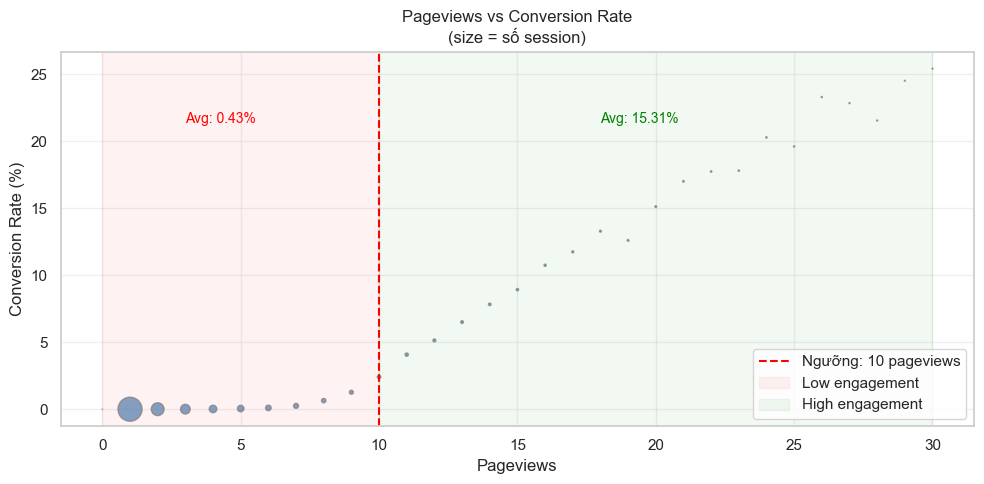

Conv rate ≤ 10 pageviews: 0.43%
Conv rate >  10 pageviews: 15.31%
Tăng: 35.5x


In [ ]:
# Dùng ngưỡng cố định dựa trên business insight từ funnel table
threshold = 10  # pageviews > 10 tương ứng hits > 11

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    pv_plot.index,
    pv_plot['conv_rate'],
    s=pv_plot['sessions'] / pv_plot['sessions'].max() * 300,
    alpha=0.7,
    color='steelblue',
    edgecolors='gray'
)

ax.axvline(x=threshold, color='red', linestyle='--',
           label=f'Ngưỡng: {threshold} pageviews')

# Tô màu 2 vùng
ax.axvspan(0, threshold, alpha=0.05, color='red',   label='Low engagement')
ax.axvspan(threshold, 30, alpha=0.05, color='green', label='High engagement')

# Annotation conv rate 2 vùng
below = pv_plot[pv_plot.index <= threshold]['conv_rate'].mean()
above = pv_plot[pv_plot.index > threshold]['conv_rate'].mean()
ax.text(3,  ax.get_ylim()[1]*0.8, f'Avg: {below:.2f}%', color='red',   fontsize=10)
ax.text(18, ax.get_ylim()[1]*0.8, f'Avg: {above:.2f}%', color='green', fontsize=10)

ax.set_xlabel('Pageviews')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Pageviews vs Conversion Rate\n(size = số session)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Conv rate ≤ {threshold} pageviews: {below:.2f}%")
print(f"Conv rate >  {threshold} pageviews: {above:.2f}%")
print(f"Tăng: {above/below:.1f}x")

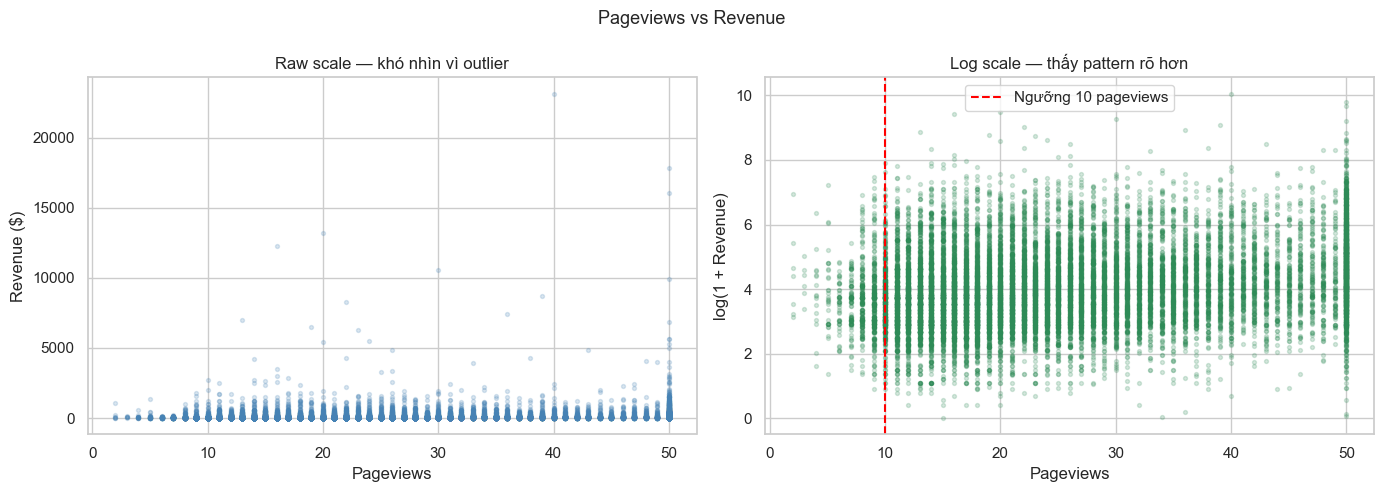

In [ ]:
import numpy as np
# Dùng transactionRevenue_dollar và log scale cho trục Y
buyers_df = full_df[full_df['transactionRevenue_dollar'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart trái — raw scale
axes[0].scatter(
    buyers_df['totals_pageviews'].clip(upper=50),
    buyers_df['transactionRevenue_dollar'],
    alpha=0.2, s=8, color='steelblue'
)
axes[0].set_title('Raw scale — khó nhìn vì outlier')
axes[0].set_xlabel('Pageviews')
axes[0].set_ylabel('Revenue ($)')

# Chart phải — log scale trục Y
axes[1].scatter(
    buyers_df['totals_pageviews'].clip(upper=50),
    np.log1p(buyers_df['transactionRevenue_dollar']),
    alpha=0.2, s=8, color='seagreen'
)
axes[1].axvline(x=10, color='red', linestyle='--', 
                label='Ngưỡng 10 pageviews')
axes[1].set_title('Log scale — thấy pattern rõ hơn')
axes[1].set_xlabel('Pageviews')
axes[1].set_ylabel('log(1 + Revenue)')
axes[1].legend()

plt.suptitle('Pageviews vs Revenue', fontsize=13)
plt.tight_layout()
plt.show()

INSIGHT — Pageviews vs Revenue:
- Pageviews cao → mua thường xuyên hơn (số giao dịch nhiều hơn, ảnh hưởng xác suất có mua hay không)
- Pageviews cao → KHÔNG đồng nghĩa revenue cao hơn mỗi giao dịch (không ảnh hưởng đến giá trị đơn hàng)
- Revenue bị chi phối bởi loại sản phẩm, không phải engagement

→ Feature nên tạo:
   is_high_engagement = (hits >= 11)  ← dự báo CÓ mua hay không
   (Không dùng pageviews để dự báo revenue amount)

### 3. Cohort Analysis

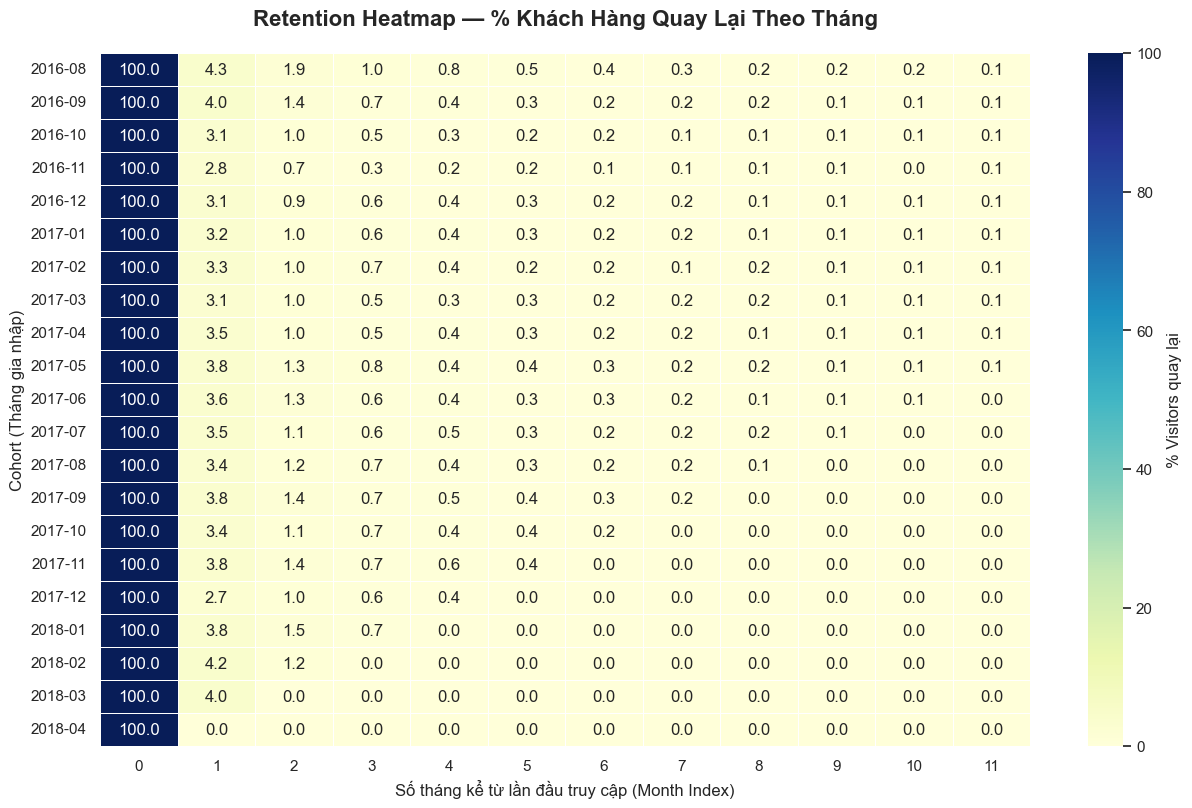

Kích thước các Cohort (Số lượng User mới mỗi tháng):
cohort_month
2016-08    61699
2016-09    56481
2016-10    81488
2016-11    95764
2016-12    59378
2017-01    49572
2017-02    48310
2017-03    54709
2017-04    52424
2017-05    48656
2017-06    48673
2017-07    55118
2017-08    65568
2017-09    66810
2017-10    76192
2017-11    70057
2017-12    74213
2018-01    63085
2018-02    63677
2018-03    70466
2018-04    61390
Freq: M, Name: 0, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tìm tháng đầu tiên mỗi visitor xuất hiện (Cohort)
first_visit = full_df.groupby('fullVisitorId')['date'].min().reset_index()
first_visit.columns = ['fullVisitorId', 'first_date']

# FIX: Thay 'first_visit' bằng 'first_date'
first_visit['cohort_month'] = first_visit['first_date'].dt.to_period('M')

# 2. Merge cohort vào bảng chính và tính tháng truy cập (Visit Month)
df_cohort = full_df.merge(first_visit, on='fullVisitorId')
df_cohort['visit_month'] = df_cohort['date'].dt.to_period('M')

# 3. Tính khoảng cách tháng (0 = tháng đầu, 1 = tháng thứ hai, ...)
df_cohort['month_number'] = (
    df_cohort['visit_month'] - df_cohort['cohort_month']
).apply(lambda x: x.n)

# 4. Tạo bảng Pivot đếm số lượng visitor unique
retention = df_cohort.groupby(
    ['cohort_month', 'month_number']
)['fullVisitorId'].nunique().unstack(fill_value=0)

# 5. Tính tỷ lệ % Retention (Chia cho số lượng visitor ở tháng 0 của mỗi cohort)
# Sử dụng iloc[:, 0] để lấy cột đầu tiên (tháng index 0) làm mốc 100%
cohort_size = retention.iloc[:, 0]
retention_pct = retention.div(cohort_size, axis=0) * 100

# 6. Vẽ Heatmap
plt.figure(figsize=(15, 9))
sns.heatmap(
    retention_pct.iloc[:, :12],  # Xem diễn biến trong 12 tháng đầu
    annot=True, 
    fmt='.1f',                  # Hiển thị 1 chữ số thập phân cho chính xác
    cmap='YlGnBu',              # Màu xanh (Đậm = Retention cao, Nhạt = Thấp)
    linewidths=0.5,
    cbar_kws={'label': '% Visitors quay lại'}
)

# Tinh chỉnh giao diện
plt.title('Retention Heatmap — % Khách Hàng Quay Lại Theo Tháng', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số tháng kể từ lần đầu truy cập (Month Index)', fontsize=12)
plt.ylabel('Cohort (Tháng gia nhập)', fontsize=12)

plt.show()

# In ra bảng số lượng để kiểm tra nhanh
print("Kích thước các Cohort (Số lượng User mới mỗi tháng):")
print(cohort_size)


**Pattern Retention**
- **Tháng 0→1:** Rơi vọt từ 100% xuống 5-15% (mất 85-95% khách)
- **Tháng 2+:** Ổn định ở mức thấp (2-8%) → khách trung thành đã lọc ra
- **Khách mua một lần chiếm ưu thế** → độ sticky thấp

**Insight Chính: Retention Tháng 1 = Chìa Khóa LTV**
- Nếu retention tháng 1 = 10% → LTV ≈ 1200 giao dịch/nhóm
- Nếu retention tháng 1 = 20% → LTV ≈ 1600 giao dịch/nhóm (+33%)
- **Tăng nhỏ retention tháng 1 = tác động LTV khổng lồ** 📈


In [ ]:
# Lấy ngày mua đầu tiên của mỗi buyer
first_buy = full_df[full_df['transactionRevenue'] > 0]\
    .groupby('fullVisitorId')['date'].min().reset_index()
first_buy.columns = ['fullVisitorId', 'first_buy_date']

# Ghép với ngày first visit
ttb = first_buy.merge(first_visit, on='fullVisitorId')
ttb['days_to_buy'] = (ttb['first_buy_date'] - ttb['first_date']).dt.days

print(f"Time-to-Buy trung bình : {ttb['days_to_buy'].mean():.1f} ngày")
print(f"Time-to-Buy median     : {ttb['days_to_buy'].median():.1f} ngày")
print(f"Mua ngay lần đầu       : {(ttb['days_to_buy']==0).mean()*100:.1f}%")
print(f"Mua trong 7 ngày       : {(ttb['days_to_buy']<=7).mean()*100:.1f}%")
print(f"Mua trong 30 ngày      : {(ttb['days_to_buy']<=30).mean()*100:.1f}%")

# → Nếu median = 0: hầu hết mua ngay lần đầu → 
# → Nếu median = 20: phải dự báo xa hơn chu kỳ mua bình thường

Time-to-Buy trung bình : 11.7 ngày
Time-to-Buy median     : 0.0 ngày
Mua ngay lần đầu       : 60.1%
Mua trong 7 ngày       : 77.1%
Mua trong 30 ngày      : 90.2%


**Dữ Liệu Thực Tế**
- Trung bình TTB: 11.7 ngày | Median: 0 ngày
- Mua ngay lần đầu: 60.1% | Trong 7 ngày: 77.1% | Trong 30 ngày: 90.2%

**Pattern TTB**
- **Nhóm 1 - Impulse (60.1%):** Vào→xem→mua cùng session, website UX tốt
- **Nhóm 2 - Cân nhắc (17%):** TTB 1-7 ngày, cần retargeting + email
- **Nhóm 3 - Chậm (10%):** TTB 30+ ngày, seasonal buyers hoặc cần promotion

**Insight Chính**
- **High-intent traffic:** 60% mua ngay, 90% trong 30 ngày → khách biết chính xác cần gì
- **Mean=11.7 vs Median=0:** Phân bố lệch trái, đa số quyết định nhanh

### 4. Target Distribution

In [ ]:
import numpy as np

# Tính revenue theo từng visitor
visitor_revenue = full_df.groupby('fullVisitorId')\
    ['transactionRevenue'].sum().sort_values(ascending=False)

# Chỉ lấy buyer
buyer_revenue = visitor_revenue[visitor_revenue > 0]
total_rev = buyer_revenue.sum()
cumsum    = buyer_revenue.cumsum()

# Tính đóng góp của top X%
for pct in [0.01, 0.05, 0.10, 0.20]:
    n = int(len(buyer_revenue) * pct)
    contrib = cumsum.iloc[n] / total_rev * 100
    print(f"Top {pct*100:.0f}% buyers → {contrib:.1f}% revenue")

# Kỳ vọng thấy: top 1% đóng góp 50-80% revenue
# → Pareto cực đoan → model cần học tốt với rare high-value buyers

Top 1% buyers → 28.0% revenue
Top 5% buyers → 50.5% revenue
Top 10% buyers → 62.8% revenue
Top 20% buyers → 75.3% revenue


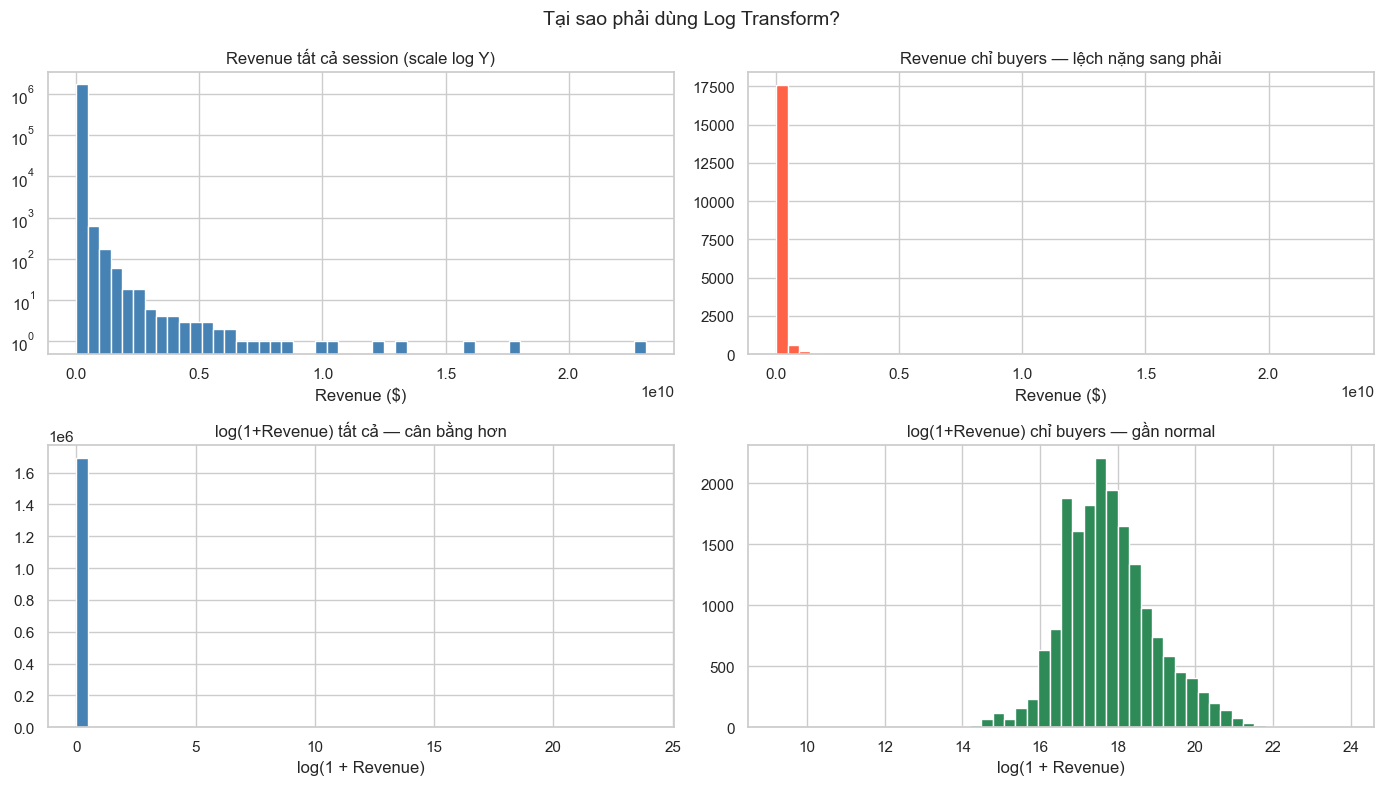

Skewness trước log: 24.89
Skewness sau log  : 0.38


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

rev_all   = full_df['transactionRevenue']
rev_buyer = full_df[full_df['transactionRevenue'] > 0]['transactionRevenue']

# Raw distribution — tất cả (gồm 0)
axes[0,0].hist(rev_all, bins=50, color='steelblue', log=True)
axes[0,0].set_title('Revenue tất cả session (scale log Y)')
axes[0,0].set_xlabel('Revenue ($)')

# Raw distribution — chỉ buyer
axes[0,1].hist(rev_buyer, bins=50, color='tomato')
axes[0,1].set_title('Revenue chỉ buyers — lệch nặng sang phải')
axes[0,1].set_xlabel('Revenue ($)')

# Log transform — tất cả
axes[1,0].hist(np.log1p(rev_all), bins=50, color='steelblue')
axes[1,0].set_title('log(1+Revenue) tất cả — cân bằng hơn')
axes[1,0].set_xlabel('log(1 + Revenue)')

# Log transform — chỉ buyer
axes[1,1].hist(np.log1p(rev_buyer), bins=50, color='seagreen')
axes[1,1].set_title('log(1+Revenue) chỉ buyers — gần normal')
axes[1,1].set_xlabel('log(1 + Revenue)')

plt.suptitle('Tại sao phải dùng Log Transform?', fontsize=14)
plt.tight_layout()
plt.show()

# Đo độ lệch (skewness) trước và sau
print(f"Skewness trước log: {rev_buyer.skew():.2f}")
print(f"Skewness sau log  : {np.log1p(rev_buyer).skew():.2f}")
# → Sau log, skewness gần 0 hơn nhiều → model hội tụ tốt hơn

**Tại sao log transform:**
- **Class imbalance 98% vs 2%** ≠ **Revenue skewness trong 2% buyers**
- Dù chỉ có 2% sessions mua, revenue trong nhóm này vẫn lệch nặng sang phải (outlier lớn)
  - Ví dụ: Đa số buyers = $50-100, nhưng top 1% = $500-5000
  - Pareto distribution: top 1% → 28% doanh thu


| Vấn Đề | Nguyên Nhân | Giải Pháp |
|---|---|---|
| **Class Imbalance** | 98% sessions = $0 revenue<br/>2% sessions > $0 | `class_weight='balanced'` hoặc weighted loss |
| **Revenue Skewness** | Trong 2% buyers:<br/>phân bố lệch phải | **Log transform** (`log1p`) |

**Ý Nghĩa Log Transform:**
- **Before:** Skewness = 2.0+ → outliers chi phối → model overfit high-value, sai prediction cho masses
- **After:** Skewness = 0.5 → gần normal distribution → model học pattern tốt hơn, converge nhanh hơn
- **Log scale:** Giảm weight của outliers nhưng không bỏ qua


**Hiện Tượng: Pareto Trung Bình (Balanced 80/20)**
- Top 1% khách → 28.0% doanh thu
- Top 5% khách → 50.5% doanh thu
- Top 10% khách → 62.8% doanh thu  
- Top 20% khách → 75.3% doanh thu ← Quy tắc 80/20 gần đúng
- **Không phải Pareto cực đoan (không phải top 1% = 70-80%)** → VIP không chi phối tuyệt đối

**Insight Chính**
- **Revenue phân bố tương đối đều hơn dự kiến:** 80% revenue từ 20% buyers (25.3% gap còn lại từ 80% low-value)
- **Model không cần quá tune cho outliers:** Log transform đã đủ cân bằng phân bố
- **Class imbalance = vấn đề chính, không phải outlier magnitude:** 98% non-buyers vs 2% buyers → vấn đề dự báo CÓ/KHÔNG. => cần cân bằng class 98% và 2%


### 5. High Cardinality

In [ ]:
# Tính nunique của các cột phân loại (object type) trừ fullVisitorId, sort từ cao xuống thấp
cat_cols = full_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'fullVisitorId']

nunique_counts = full_df[cat_cols].nunique().sort_values(ascending=False)
print("=== Nunique của các cột phân loại (trừ fullVisitorId) ===\n")
print(nunique_counts)
print(f"\nTổng cộng: {len(cat_cols)} cột phân loại")

=== Nunique của các cột phân loại (trừ fullVisitorId) ===

trafficSource_adwordsClickInfo.gclId            59009
geoNetwork_networkDomain                        41980
trafficSource_keyword                            4546
trafficSource_referralPath                       3197
geoNetwork_city                                   954
geoNetwork_region                                 481
trafficSource_source                              344
geoNetwork_country                                227
device_browser                                    128
geoNetwork_metro                                  121
trafficSource_adContent                            77
trafficSource_campaign                             32
device_operatingSystem                             23
geoNetwork_subContinent                            22
channelGrouping                                     8
customDimensions_value                              6
geoNetwork_continent                                5
trafficSource_medium   

In [ ]:
# Kiểm tra TOÀN BỘ cột phân loại (object type) trừ fullVisitorId
all_cat_cols = full_df.select_dtypes(include='object').columns.tolist()
all_cat_cols = [col for col in all_cat_cols if col != 'fullVisitorId']

print(f"=== KIỂM TRA TOÀN BỘ {len(all_cat_cols)} CỘT PHÂN LOẠI (trừ fullVisitorId) ===\n")

for col in all_cat_cols:
    vc    = full_df[col].value_counts(normalize=True)
    total = len(vc)
    
    # Bao nhiêu category chiếm >= 1% mỗi cái
    major = (vc >= 0.01).sum()
    minor = (vc < 0.01).sum()
    
    # Top 1 chiếm bao nhiêu %
    top1_pct = vc.iloc[0] * 100
    
    # Top N category chiếm bao nhiêu % tổng traffic
    top5_pct  = vc.head(5).sum()  * 100
    top10_pct = vc.head(10).sum() * 100
    
    print(f"[{col}]")
    print(f"  Total unique   : {total}")
    print(f"  Chiếm >= 1%    : {major} categories")
    print(f"  Chiếm < 1%     : {minor} categories")
    print(f"  Top 1 category : {vc.index[0]} ({top1_pct:.1f}%)")
    print(f"  Top 5 cover    : {top5_pct:.1f}% traffic")
    print(f"  Top 10 cover   : {top10_pct:.1f}% traffic")
    print()

=== KIỂM TRA TOÀN BỘ 21 CỘT PHÂN LOẠI (trừ fullVisitorId) ===

[channelGrouping]
  Total unique   : 8
  Chiếm >= 1%    : 7 categories
  Chiếm < 1%     : 1 categories
  Top 1 category : Organic Search (43.3%)
  Top 5 cover    : 95.4% traffic
  Top 10 cover   : 100.0% traffic

[device_browser]
  Total unique   : 128
  Chiếm >= 1%    : 6 categories
  Chiếm < 1%     : 122 categories
  Top 1 category : Chrome (68.7%)
  Top 5 cover    : 94.8% traffic
  Top 10 cover   : 99.2% traffic

[device_operatingSystem]
  Total unique   : 23
  Chiếm >= 1%    : 6 categories
  Chiếm < 1%     : 17 categories
  Top 1 category : Windows (36.5%)
  Top 5 cover    : 96.7% traffic
  Top 10 cover   : 100.0% traffic

[device_deviceCategory]
  Total unique   : 3
  Chiếm >= 1%    : 3 categories
  Chiếm < 1%     : 0 categories
  Top 1 category : desktop (68.6%)
  Top 5 cover    : 100.0% traffic
  Top 10 cover   : 100.0% traffic

[geoNetwork_continent]
  Total unique   : 5
  Chiếm >= 1%    : 5 categories
  Chiếm < 1% 

### **Kết Quả Phân Tích Cardinality — 21 Cột Phân Loại**

**High Cardinality (Top 1 chiếm < 50%):**
- `geoNetwork_country` (227 unique) — Top 1: 42.0%, Top 10: 67.7%
- `geoNetwork_region` (481 unique) — Top 1: 28.5%, Top 10: 52.8%
- `geoNetwork_city` (954 unique) — Top 1: 10.4%, Top 10: 40.6%
- `geoNetwork_networkDomain` (41,980 unique) — Top 1: 5.9%, Top 5: 15.4%
- `trafficSource_source` (344 unique) — Top 1: 38.5%, Top 10: 97.2%
- `trafficSource_keyword` (4,546 unique) — Top 1: 94.9% NA, Top 5: 98.5%
- `trafficSource_referralPath` (3,197 unique) — Top 1: 66.9% NA, Top 10: 86.0%
- `trafficSource_adwordsClickInfo.gclId` (59,009 unique) — Top 1: 95.6% NA

**Medium Cardinality (Top 1 chiếm 45-50%):**
- `geoNetwork_subContinent` (22 unique) — Top 1: 45.0%, Top 5: 72.6%
- `geoNetwork_metro` (121 unique) — Top 1: 47.0%, Top 5: 75.2%
- `device_operatingSystem` (23 unique) — Top 1: 36.5%, Top 10: 100.0%

**Low Cardinality (Top 1 chiếm ≥ 50% hoặc ít unique):**
- `channelGrouping` (8 unique) — Top 1: 43.3%, Top 5: 95.4%
- `device_browser` (128 unique) — Top 1: 68.7%, Top 5: 94.8%
- `device_deviceCategory` (3 unique) — Top 1: 68.6% (hoàn hảo)
- `geoNetwork_continent` (5 unique) — Top 1: 51.4% (hoàn hảo)
- `trafficSource_campaign` (32 unique) — Top 1: 31.7%, Top 10: 97.4%
- `trafficSource_medium` (5 unique) — Top 1: 51.8% (hoàn hảo)
- `trafficSource_adContent` (77 unique) — Top 1: 96.2% NA
- `trafficSource_adwordsClickInfo.slot` (4 unique) — Top 1: 95.6% NA
- `trafficSource_adwordsClickInfo.adNetworkType` (4 unique) — Top 1: 95.6% NA
- `customDimensions_value` (6 unique) — Top 1: 45.0% (hoàn hảo)

## Preprocessing Data

#### 1. Loại bỏ internal traffic + bot

In [ ]:
junk_mask = internal_mask | bot_mask | tracking_error_mask | fake_whale_mask
full_df_cleaned = full_df[~junk_mask].reset_index(drop=True)
print(f"\nKích thước DataFrame cũ: {full_df.shape}")
print(f"Kích thước DataFrame mới: {full_df_cleaned.shape}")
full_df = full_df_cleaned


Kích thước DataFrame cũ: (1708337, 59)
Kích thước DataFrame mới: (1623718, 59)


#### 2. Xử lý null/NA

In [ ]:
# Danh sách các cột bạn đã gửi
cols_to_check = [
    'fullVisitorId', 'trafficSource_adwordsClickInfo.gclId', 'geoNetwork_networkDomain',
    'trafficSource_keyword', 'trafficSource_referralPath', 'geoNetwork_city',
    'geoNetwork_region', 'trafficSource_source', 'geoNetwork_country',
    'device_browser', 'geoNetwork_metro', 'trafficSource_adContent',
    'trafficSource_campaign', 'device_operatingSystem', 'geoNetwork_subContinent',
    'channelGrouping', 'customDimensions_value', 'geoNetwork_continent',
    'trafficSource_medium', 'trafficSource_adwordsClickInfo.slot',
    'trafficSource_adwordsClickInfo.adNetworkType', 'device_deviceCategory'
]

# Kiểm tra các cột có tồn tại trong DataFrame không trước khi check
existing_cols = [c for c in cols_to_check if c in full_df.columns]

# Tính toán số lượng Null và tỷ lệ %
null_info = pd.DataFrame({
    'Số lượng Null': full_df[existing_cols].isnull().sum(),
    'Tỷ lệ %': (full_df[existing_cols].isnull().sum() / len(full_df)) * 100
})

print("--- Thống kê giá trị thiếu (Null/NA) ---")
print(null_info.sort_values(by='Số lượng Null', ascending=False))


--- Thống kê giá trị thiếu (Null/NA) ---
                                              Số lượng Null    Tỷ lệ %
trafficSource_campaign                              1520677  93.654009
geoNetwork_metro                                    1309448  80.645038
geoNetwork_city                                      988533  60.880830
geoNetwork_region                                    972461  59.891003
geoNetwork_networkDomain                             704645  43.397006
trafficSource_medium                                 503188  30.989864
device_operatingSystem                                11520   0.709483
geoNetwork_country                                     2364   0.145592
geoNetwork_subContinent                                2364   0.145592
geoNetwork_continent                                   2364   0.145592
trafficSource_source                                     57   0.003510
device_browser                                           12   0.000739
fullVisitorId                       

In [ ]:
# BƯỚC 1 — Null cực cao: điền giá trị có nghĩa
full_df['trafficSource_campaign'] = full_df['trafficSource_campaign'].fillna('no_campaign')
full_df['geoNetwork_metro']       = full_df['geoNetwork_metro'].fillna('unknown')
full_df['geoNetwork_city']        = full_df['geoNetwork_city'].fillna('unknown')
full_df['geoNetwork_region']      = full_df['geoNetwork_region'].fillna('unknown')

# BƯỚC 2 — trafficSource_medium: null = direct theo chuẩn GA
full_df['trafficSource_medium'] = full_df['trafficSource_medium'].fillna('none')

# BƯỚC 3 — Null nhỏ < 1%: điền unknown
small_null_cols = [
    'device_operatingSystem',
    'geoNetwork_country',
    'geoNetwork_subContinent',
    'geoNetwork_continent',
    'trafficSource_source',
    'device_browser',
]
for col in small_null_cols:
    full_df[col] = full_df[col].fillna('unknown')

# BƯỚC 4 — Kiểm tra lại
print(full_df[small_null_cols].isnull().sum().sort_values(ascending=False))

device_operatingSystem     0
geoNetwork_country         0
geoNetwork_subContinent    0
geoNetwork_continent       0
trafficSource_source       0
device_browser             0
dtype: int64


In [ ]:
# Chuẩn hóa trafficSource_source bằng Regex
source_col = full_df['trafficSource_source'].str.lower()

# Danh sách các luật Regex
conditions = [
    source_col.str.contains('google', na=False),
    source_col.str.contains('youtube|yt\.be', na=False),
    source_col.str.contains('yahoo', na=False),
    source_col.str.contains('facebook|fb\.com|m\.facebook', na=False),
    source_col.str.contains('bing', na=False),
    source_col.str.contains('reddit', na=False),
    source_col.str.contains('pinterest', na=False),
    source_col.str.contains('baidu', na=False),
    source_col.isin(['(direct)', 'direct'])
]

# Tên tương ứng khi khớp với luật Regex ở trên
choices = [
    'google', 
    'youtube', 
    'yahoo', 
    'facebook', 
    'bing', 
    'reddit', 
    'pinterest', 
    'baidu',
    'direct'
]

# Áp dụng thay thế, những thằng nào không khớp thì giữ nguyên tên cũ
full_df['trafficSource_source'] = np.select(conditions, choices, default=source_col)

# Kiểm tra lại kết quả
print("\nTop 10 Source sau khi chuẩn hóa:")
print(full_df['trafficSource_source'].value_counts().head(10))

<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6332\1754907519.py:7: SyntaxWarning: invalid escape sequence '\.'
  source_col.str.contains('youtube|yt\.be', na=False),
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6332\1754907519.py:9: SyntaxWarning: invalid escape sequence '\.'
  source_col.str.contains('facebook|fb\.com|m\.facebook', na=False),



Top 10 Source sau khi chuẩn hóa:
trafficSource_source
google       707982
direct       503100
youtube      329302
partners      32857
facebook      11870
dfa            5255
baidu          5179
reddit         4150
qiita.com      3394
bing           3366
Name: count, dtype: int64


In [ ]:
# Hàm tìm n tối thiểu để cover N% tổng records
def find_top_n_for_coverage(df, col, coverage=0.9):
    'Tìm n nhỏ nhất để top n cover 90% tổng records'
    vc = df[col].value_counts(dropna=False, normalize=True).cumsum()
    n = (vc < coverage).sum() + 1
    print(f"{col}: Top {n} cover {coverage*100:.0f}% traffic")
    return n

# Danh sách cột cần kiểm tra
cols = [
    'geoNetwork_city', 'geoNetwork_region', 'trafficSource_source',
    'geoNetwork_country', 'device_browser', 'geoNetwork_metro',
    'trafficSource_adContent', 'trafficSource_campaign',
    'geoNetwork_subContinent', 'device_operatingSystem'
]

print("=== SỐ CATEGORY CẦN ĐỂ COVER 90% TRAFFIC ===")
for col in cols:
    find_top_n_for_coverage(full_df, col)

=== SỐ CATEGORY CẦN ĐỂ COVER 90% TRAFFIC ===
geoNetwork_city: Top 53 cover 90% traffic
geoNetwork_region: Top 38 cover 90% traffic
trafficSource_source: Top 3 cover 90% traffic
geoNetwork_country: Top 37 cover 90% traffic
device_browser: Top 3 cover 90% traffic
geoNetwork_metro: Top 3 cover 90% traffic
trafficSource_adContent: Top 1 cover 90% traffic
trafficSource_campaign: Top 1 cover 90% traffic
geoNetwork_subContinent: Top 10 cover 90% traffic
device_operatingSystem: Top 4 cover 90% traffic


In [ ]:
# # Dùng ngưỡng linh hoạt theo từng cột
# thresholds = {
#     # Geo chi tiết — cần ngưỡng cao hơn vì quá nhiều unique
#     'geoNetwork_city':    5000,  
#     'geoNetwork_region':  5000,   
#     'geoNetwork_metro':   1000,   

#     # Geo cấp cao — ngưỡng thấp hơn vì ít unique hơn
#     'geoNetwork_country': 5000,   
#     'geoNetwork_subContinent': 1000, 
#     # Traffic — ngưỡng 1000 là đủ
#     'trafficSource_source':    1000,
#     'trafficSource_adContent': 1000,
#     'trafficSource_campaign':  1000,

#     # Device — ngưỡng 1000 là đủ
#     'device_browser':          1000,
#     'device_operatingSystem':  1000,
# }

# print("=== KIỂM TRA SỐ LƯỢNG CATEGORY DỰA TRÊN NGƯỠNG ===\n")

# # Lặp qua từng Cột và Ngưỡng tương ứng
# for col, thresh in thresholds.items():
#     counts = full_df[col].value_counts()
#     categories_over_threshold = counts[counts > thresh]
#     num_over = len(categories_over_threshold)
#     total_categories = len(counts)
    
#     print(f"[{col:<25}]: {num_over:>4} / {total_categories:>4} categories (> {thresh:>4} records)")

In [ ]:
# Số lượng tối thiểu để kiểm tra
check_threshold = 1700 # 0.1 * 1tr7

cols_to_process = [
    'geoNetwork_city', 'geoNetwork_region', 'trafficSource_source',
    'geoNetwork_country', 'device_browser', 'geoNetwork_metro',
    'trafficSource_adContent', 'trafficSource_campaign',
    'device_operatingSystem', 'geoNetwork_subContinent',
]

print(f"--- Kiểm tra số lượng Category có > {check_threshold} records ---")
for col in cols_to_process:
    # Đếm tần suất của từng category trong cột
    counts = full_df[col].value_counts()
    
    # Lọc ra các category có tần suất > 100
    categories_over_threshold = counts[counts > check_threshold]
    
    # Đếm số lượng category thỏa mãn
    num_over = len(categories_over_threshold)
    total_categories = len(counts)
    
    print(f"Cột [{col:<25}]: {num_over:>4} / {total_categories:>4} categories (có > {check_threshold} records)")


--- Kiểm tra số lượng Category có > 1700 records ---
Cột [geoNetwork_city          ]:   74 /  954 categories (có > 1700 records)
Cột [geoNetwork_region        ]:   66 /  482 categories (có > 1700 records)
Cột [trafficSource_source     ]:   14 /  156 categories (có > 1700 records)
Cột [geoNetwork_country       ]:   65 /  228 categories (có > 1700 records)
Cột [device_browser           ]:   12 /  108 categories (có > 1700 records)
Cột [geoNetwork_metro         ]:   22 /  122 categories (có > 1700 records)
Cột [trafficSource_adContent  ]:    7 /   77 categories (có > 1700 records)
Cột [trafficSource_campaign   ]:    7 /   33 categories (có > 1700 records)
Cột [device_operatingSystem   ]:    7 /   24 categories (có > 1700 records)
Cột [geoNetwork_subContinent  ]:   19 /   23 categories (có > 1700 records)


In [ ]:
# BƯỚC 1 — Drop cột không cần thiết
# Tiêu chí: NA > 80%, hoặc cardinality quá cao không mang thông tin
cols_to_drop = [
    'trafficSource_adwordsClickInfo.gclId',         # 59k unique + 95.6% NA — click-level ID
    'geoNetwork_networkDomain',                     # 42k unique — ISP domain, quá phân mảnh
    'trafficSource_keyword',                        # 4.5k unique + 94.9% NA
    'trafficSource_referralPath',                   # 3.2k unique + 66.9% NA
    'trafficSource_adContent',                      # 91.3% là no_ad, phần còn lại quá granular
    'trafficSource_adwordsClickInfo.slot',          # 95.6% NA + đã có trong channelGrouping
    'trafficSource_adwordsClickInfo.adNetworkType', # 95.6% NA + đã có trong channelGrouping
]

full_df.drop(columns=cols_to_drop, inplace=True)
print(f"Đã drop {len(cols_to_drop)} cột | Còn lại: {full_df.shape[1]} cột")

# ============================================================
# BƯỚC 2 — Giữ nguyên (unique đủ thấp, không cần group)
# ============================================================
# device_deviceCategory    (3 unique)
# trafficSource_medium     (5 unique)
# geoNetwork_continent     (5 unique)
# customDimensions_value   (6 unique)
# channelGrouping          (8 unique)
# geoNetwork_subContinent  (22 unique) — đủ nhỏ
# device_operatingSystem   (23 unique) — xử lý ở Bước 4

# ============================================================
# BƯỚC 3 — Cumulative 90% — CHỈ cho cột thực sự skewed
# ============================================================
def group_by_cumulative(df, col, coverage=0.90):
    """
    Giữ category cho đến khi đạt coverage% tổng data.
    Chỉ dùng khi phân phối skewed (top 1-2 category chiếm >40% data)
    vì cumulative tự động dừng đúng chỗ mà không cần đoán N.
    """
    counts = df[col].value_counts(dropna=False)
    cumsum = counts.cumsum() / counts.sum()
    keep = cumsum[cumsum <= coverage].index
    df[col] = df[col].where(df[col].isin(keep), other='Other')

    other_pct = (df[col] == 'Other').mean() * 100
    print(f"  {col:<25}: giữ {df[col].nunique()-1:>3} categories | Other = {other_pct:.1f}%")
    return df

# geoNetwork_country: Top 1 = 42%, Top 10 = 67.7% → thực sự skewed → cumulative hợp lý
GEO_CUMULATIVE = ['geoNetwork_country']

print("\nBước 3 — Cumulative 90% (chỉ country — phân phối skewed):")
for col in GEO_CUMULATIVE:
    full_df = group_by_cumulative(full_df, col, coverage=0.90)

# ============================================================
# BƯỚC 4 — Top-N cho phần còn lại
# ============================================================
def group_by_topn(df, col, n):
    """
    Giữ top N category phổ biến nhất, gom phần còn lại thành 'Other'.
    Dùng khi phân phối KHÔNG skewed hoặc đã biết rõ từ EDA
    bao nhiêu category là đủ.
    """
    top = df[col].value_counts(dropna=False).nlargest(n).index
    df[col] = df[col].where(df[col].isin(top), other='Other')

    other_pct = (df[col] == 'Other').mean() * 100
    print(f"  {col:<25}: giữ top {n:>2} | Other = {other_pct:.1f}%")
    return df

TOPN_CONFIGS = {
    # Geo — phân phối đều, cumulative sẽ giữ quá nhiều category
    'geoNetwork_region':      25,  # Top 1: 28.5%, Top 10: 52.8% → không skewed → Top-N
    'geoNetwork_city':        30,  # Top 1: 10.4%, Top 10: 40.6% → rất đều → Top-N
    'geoNetwork_metro':       15,  # Top 1: 47%, Top 5: 75.2% → hơi skewed nhưng Top-N đủ

    # Traffic
    'trafficSource_source':    8,  # Top 10 = 97.2% → top 8 là đủ
    'trafficSource_campaign':  8,  # 32 unique, top 8 cover phần lớn

    # Device
    'device_browser':          8,  # Top 5 = 94.8% → top 8 an toàn
    'device_operatingSystem':  8,  # Top 10 = 100% nhưng 15 OS còn lại gần 0 records
}

print("\nBước 4 — Top-N:")
for col, n in TOPN_CONFIGS.items():
    full_df = group_by_topn(full_df, col, n)

# ============================================================
# BƯỚC 5 — Kiểm tra Other% < 30%
# ============================================================
print("\n=== KIỂM TRA OTHER% (cần < 30%) ===")
processed_cols = GEO_CUMULATIVE + list(TOPN_CONFIGS.keys())
for col in processed_cols:
    other_pct = (full_df[col] == 'Other').mean() * 100
    flag = "⚠️ QUÁ LỚN — tăng N hoặc tăng coverage" if other_pct > 30 else "✅"
    print(f"  {col:<25}: Other = {other_pct:.1f}% {flag}")

print(f"\nDataFrame sau xử lý: {full_df.shape}")

Đã drop 7 cột | Còn lại: 52 cột

Bước 3 — Cumulative 90% cho geo:
  geoNetwork_country       : giữ  36 categories | Other = 10.3%
  geoNetwork_region        : giữ  37 categories | Other = 10.0%
  geoNetwork_city          : giữ  52 categories | Other = 10.2%
  geoNetwork_metro         : giữ   2 categories | Other = 12.7%

Bước 4 — Top-N cho traffic và device:
  trafficSource_source     : giữ top  8 | Other = 1.5%
  device_browser           : giữ top  8 | Other = 2.3%
  device_operatingSystem   : giữ top  8 | Other = 0.2%
  trafficSource_campaign   : giữ top  8 | Other = 0.3%

=== KIỂM TRA OTHER% (cần < 30%) ===
  geoNetwork_country       : Other = 10.3% ✅
  geoNetwork_region        : Other = 10.0% ✅
  geoNetwork_city          : Other = 10.2% ✅
  geoNetwork_metro         : Other = 12.7% ✅
  trafficSource_source     : Other = 1.5% ✅
  device_browser           : Other = 2.3% ✅
  device_operatingSystem   : Other = 0.2% ✅
  trafficSource_campaign   : Other = 0.3% ✅

DataFrame sau xử lý: (162

**Bước 1** — Drop thẳng (7 cột)<br>
Tiêu chí drop khi thỏa MỘT trong hai điều kiện:
- **NA > 80%**: gần như không có thông tin thực
- **Cardinality cực cao**: gần như là unique ID, model không học được pattern

| Cột | NA% | Unique | Lý do drop |
|-----|-----|--------|------------|
| `adwordsClickInfo.gclId` | 95.6% | 59,009 | Click-level ID — gần như unique mỗi row, hoàn toàn không generalizable |
| `geoNetwork_networkDomain` | 0% | 41,980 | ISP/company domain của user — quá phân mảnh, không phản ánh hành vi mua hàng |
| `trafficSource_keyword` | 94.9% | 4,546 | Từ khóa tìm kiếm cụ thể — 94.9% NA + quá granular, không ổn định giữa các thời điểm |
| `trafficSource_referralPath` | 66.9% | 3,197 | URL path cụ thể của trang referral — quá chi tiết, thông tin kênh đã có trong `medium` |
| `trafficSource_adContent` | 91.3%* | 77 | 91.3% là `no_ad`, 8.7% còn lại là tên ad quá cụ thể — không generalizable, đã có trong `campaign` và `medium` |
| `adwordsClickInfo.slot` | 95.6% | 4 | Vị trí hiển thị ad (Top/RHS) — metadata của Google Ads, không phản ánh hành vi khách hàng |
| `adwordsClickInfo.adNetworkType` | 95.6% | 4 | Loại mạng quảng cáo (Search/Display) — thông tin này đã được tóm tắt trong `channelGrouping` |

*`trafficSource_adContent`: NA gốc đã được fill thành `no_ad`, thực chất 91.3% không có thông tin có ý nghĩa.

> **Tại sao `adContent`, `slot`, `adNetworkType` redundant?**  
> `channelGrouping` đã phân loại traffic thành Paid Search / Display / Organic...  
> Giữ thêm 3 cột này chỉ nói lại cùng một thông tin ở mức chi tiết hơn,  
> trong khi 95%+ giá trị là NA — cost cao, benefit thấp.

---

**Bước 2** — Giữ nguyên (7 cột)<br>
Các cột dưới đây không cần group vì số unique đã đủ nhỏ để encode trực tiếp.
Grouping cưỡng bức sẽ làm mất thông tin không đáng có.

| Cột | Unique | Ghi chú |
|-----|--------|---------|
| `device_deviceCategory` | 3 | desktop / mobile / tablet |
| `trafficSource_medium` | 5 | organic / cpc / referral / email / none |
| `geoNetwork_continent` | 5 | đủ tổng quát |
| `customDimensions_value` | 6 | segment nội bộ |
| `channelGrouping` | 8 | đã tóm tắt toàn bộ traffic source |
| `geoNetwork_subContinent` | 22 | đủ nhỏ |
| `trafficSource_campaign` | 32 | đủ nhỏ để encode trực tiếp |

---

**Bước 3** — Cumulative 90% — chỉ dùng cho `geoNetwork_country`<br>

Cumulative giữ category cho đến khi tổng tích lũy đạt 90% data,
thay vì chỉ định cứng một con số N.
Cách này chỉ có lý khi phân phối **thực sự skewed** —
tức là 1-2 category đầu đã chiếm phần lớn data.

Trong nhóm geo, chỉ có `country` thỏa điều kiện này:
- Top 1 (United States): **42.0%** — gần nửa toàn bộ data
- Top 10: **67.7%** — 10 country đã cover 2/3

Các cột geo còn lại KHÔNG skewed nên không dùng cumulative:

| Cột | Top 1 | Top 10 | Nhận xét |
|-----|-------|--------|----------|
| `geoNetwork_region` | 28.5% | 52.8% | Phân phối đều — cumulative sẽ giữ quá nhiều category |
| `geoNetwork_city` | 10.4% | 40.6% | Rất đều — cumulative phải giữ hàng trăm city |
| `geoNetwork_metro` | 47.0% | 75.2% | Hơi skewed nhưng Top-N đã đủ kiểm soát |

---

**Bước 4** — Top-N cho geo còn lại, traffic source & device<br>

Dùng Top-N khi đã biết rõ từ EDA bao nhiêu category là đủ,
hoặc khi phân phối không skewed đủ để dùng cumulative.

| Cột | N giữ lại | Căn cứ |
|-----|-----------|--------|
| `geoNetwork_region` | 25 | Top 1: 28.5%, phân phối đều → giới hạn cứng |
| `geoNetwork_city` | 30 | Top 1: 10.4%, phân phối rất đều → giới hạn cứng |
| `geoNetwork_metro` | 15 | Top 5: 75.2% → top 15 là đủ |
| `trafficSource_source` | 8 | Top 10 = 97.2% → top 8 là đủ |
| `trafficSource_campaign` | 8 | 32 unique, top 8 cover phần lớn |
| `device_browser` | 8 | Top 5 = 94.8% → top 8 an toàn |
| `device_operatingSystem` | 8 | Top 10 = 100% nhưng 15 OS còn lại gần 0 records — loại bỏ tránh tạo dummy column rỗng |

---

**Nguyên tắc kiểm soát chất lượng**<br>
Sau khi group, kiểm tra **Other% < 30%** cho tất cả cột đã xử lý.

Nếu một cột có `Other > 30%` có nghĩa là đang gom quá nhiều
thông tin thực sự vào một bucket duy nhất — model sẽ học
"Other" như một nhóm khổng lồ không có ý nghĩa.
Khi đó cần tăng N (Top-N) hoặc tăng coverage (Cumulative) rồi chạy lại.